In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader


In [3]:
df = pd.read_excel(r"C:\Users\Bereket\Desktop\Attribute Values (1)\Merged_Woredas_75k.xlsx")

In [4]:
print(df.describe())
print(df.info())
print(df.isnull().sum())
print(df.count)
print(df.columns)

           Latitude     Longitude  Aspect (Degree)  Drainage Density (m)  \
count  75000.000000  75000.000000     75000.000000          74907.000000   
mean       9.772499     39.557323       171.306174            960.466101   
std        0.505722      0.341054       102.554724           1115.567633   
min        8.718917     38.659892        -1.000000              0.000000   
25%        9.472561     39.370320        90.000000              0.000000   
50%        9.964743     39.676158       157.009003            579.388000   
75%       10.115077     39.800414       261.639503           1481.520020   
max       10.553815     40.096906       359.846985           8316.169922   

       Elevation (m)    NDVI_Value  Plan Curvature  Profile Curvature  \
count   75000.000000  75000.000000    7.500000e+04       7.500000e+04   
mean     1982.604987      0.137990    1.592602e+07       9.300111e+06   
std       630.890561      0.053530    1.116233e+09       1.288965e+09   
min       973.000000   

In [5]:
terrain_cols = ["Elevation (m)", "Slope (Degree)", "TPI", "TRI"]
imputer = KNNImputer(n_neighbors=5)
df[terrain_cols] = imputer.fit_transform(df[terrain_cols])

In [6]:
df["Drainage Density (m)"] = (
    df.groupby("Woreda")["Drainage Density (m)"]
      .transform(lambda x: x.fillna(x.median()))
)

In [7]:

coords = df[["Latitude", "Longitude"]]
known = df["Soil Type"].notna()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(coords[known], df.loc[known, "Soil Type"])

df.loc[~known, "Soil Type"] = knn.predict(coords[~known])

In [8]:
df["Geology_Formation"] = df["Geology_Formation"].fillna("Unknown")
df['Geology_Formation'].unique()

array(['Alaiae Formation', 'Tarmaber Megezez Formation',
       'Ashangi Formation', 'Nazret Series',
       'Tarmaber-Meaezez Formations', 'Antalo Formation',
       'Alajae Formation', 'Amba Aradom Formation', 'Quaternary Basalt',
       'Abay Formation', 'Rhyolitic Volcanic Complexes', 'Unknown'],
      dtype=object)

In [9]:
df.isnull().sum()

Latitude                    0
Longitude                   0
Aspect (Degree)             0
Drainage Density (m)        0
Elevation (m)               0
Ferrous Materials           0
Geology_Formation           0
Land_Use                    0
NDVI_Value                  0
Plan Curvature              0
Profile Curvature           0
Rainfall (mm)               0
Slope (Degree)              0
Soil Type                   0
SPI                     16445
TPI                         0
TRI                         0
TWI                         0
Woreda                      0
dtype: int64

In [10]:
df['Aspect (Degree)'] = df['Aspect (Degree)'].replace(-1, np.nan)

In [11]:
df['Aspect (Degree)'].min(), df['Aspect (Degree)'].max()

(0.0, 359.8469849)

In [12]:
# Convert degrees to radians
aspect_rad = np.deg2rad(df['Aspect (Degree)'])

# Create circular components
df['Aspect_sin'] = np.sin(aspect_rad)
df['Aspect_cos'] = np.cos(aspect_rad)

# Fill NaNs (flat areas) with 0
df[['Aspect_sin', 'Aspect_cos']] = df[['Aspect_sin', 'Aspect_cos']].fillna(0)

# Drop original aspect
df = df.drop(columns=['Aspect (Degree)'])


In [13]:
df = df.drop(columns=["SPI"])

In [14]:
df.isnull().sum()

Latitude                0
Longitude               0
Drainage Density (m)    0
Elevation (m)           0
Ferrous Materials       0
Geology_Formation       0
Land_Use                0
NDVI_Value              0
Plan Curvature          0
Profile Curvature       0
Rainfall (mm)           0
Slope (Degree)          0
Soil Type               0
TPI                     0
TRI                     0
TWI                     0
Woreda                  0
Aspect_sin              0
Aspect_cos              0
dtype: int64

In [15]:
# 1 Select categorical columns (object or category type)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", categorical_cols)

#  Display unique values for each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col} - {df[col].nunique()} unique values")
    print(df[col].unique())


Categorical columns: Index(['Ferrous Materials', 'Geology_Formation', 'Land_Use', 'Soil Type',
       'Woreda'],
      dtype='object')

Column: Ferrous Materials - 2 unique values
['Soil' 'Minerals']

Column: Geology_Formation - 12 unique values
['Alaiae Formation' 'Tarmaber Megezez Formation' 'Ashangi Formation'
 'Nazret Series' 'Tarmaber-Meaezez Formations' 'Antalo Formation'
 'Alajae Formation' 'Amba Aradom Formation' 'Quaternary Basalt'
 'Abay Formation' 'Rhyolitic Volcanic Complexes' 'Unknown']

Column: Land_Use - 9 unique values
['Cropland' 'Trees cover areas' 'Shrubs cover areas' 'Grassland'
 'Built up areas' 'Vegetation aquatic' 'Bare areas' 'Open water'
 'Trees cover areas0']

Column: Soil Type - 6 unique values
['Pellic Vertisol' 'Eutric Cambisol' 'Cambie Arenosol' 'Ferralic Cambisol'
 'Eutric Regosol' 'Calcic Xerosol']

Column: Woreda - 5 unique values
['Kewet' 'Ankober' 'Merabete' 'Menjar' 'Menze Gera']


In [16]:
# 1. R FACTOR (Rainfall Erosivity) - Hurni (1985)
# ==========================================
df['R'] = -8.12 + (0.562 * df['Rainfall (mm)'])
df['R'] = df['R'].clip(lower=0) 

# ==========================================
# 2. K FACTOR (Soil Erodibility)
# ==========================================
soil_k_map = {
    'Cambic Arenosol': 0.25,
    'Ferralic Cambisol': 0.30,
    'Eutric Cambisol': 0.28,
    'Eutric Nitisol': 0.15,
    'Pellic Vertisol': 0.25,
    'Lithosol': 0.10,
    # Ensure all your soil types are covered or use a default
}
df['K'] = df['Soil Type'].map(soil_k_map).fillna(0.2)

# ==========================================
# 3. LS FACTOR (The "Missing DEM" Fix)
# Method: Wischmeier & Smith (1978) 
# ==========================================

# A. ESTIMATE SLOPE LENGTH (lambda) FROM LAND USE
# Logic: Water flows further on bare land/roads than in forests.
# These values are estimates (in meters). You can adjust them if you have local data.
slope_length_map = {
    'Cropland': 60,            # Typical plow length/terrace spacing
    'Vegetation aquatic': 10,  # Short effective length
    'Grassland': 20,           # Grass obstructs flow quickly
    'Shrubs cover areas': 30,
    'Trees cover areas': 15,   # High infiltration breaks flow
    'Bare areas': 90,          # Long uninterrupted flow
    'Built up areas': 100,     # Artificial channels/long flow
    'Open water': 0,           # No erosion
    'Sparse vegetation': 50
}

# If 'Land_Use' column exists, map it. Otherwise assume a moderate length (e.g., 50m)
if 'Land_Use' in df.columns:
    df['Slope_Length_m'] = df['Land_Use'].map(slope_length_map).fillna(50)
else:
    df['Slope_Length_m'] = 50 

# B. CALCULATE LS USING CLASSIC FORMULA
# Convert slope degrees to percent and radians
slope_rad = np.deg2rad(df['Slope (Degree)'])
slope_pct = np.tan(slope_rad) * 100

# Determine 'm' exponent based on slope steepness (Wischmeier & Smith)
# m = 0.5 if slope > 5%, 0.4 if 3-5%, 0.3 if 1-3%, 0.2 if < 1%
conditions_m = [
    (slope_pct >= 5),
    (slope_pct >= 3) & (slope_pct < 5),
    (slope_pct >= 1) & (slope_pct < 3),
    (slope_pct < 1)
]
values_m = [0.5, 0.4, 0.3, 0.2]
df['m_exponent'] = np.select(conditions_m, values_m, default=0.5)

# Calculate L (Length Factor)
# L = (lambda / 22.13)^m
L_factor = (df['Slope_Length_m'] / 22.13) ** df['m_exponent']

# Calculate S (Steepness Factor) - McCool et al. (1987) variant for RUSLE
# For S < 9%: 10.8 * sin(theta) + 0.03
# For S >= 9%: 16.8 * sin(theta) - 0.50
S_factor = np.where(
    slope_pct < 9,
    10.8 * np.sin(slope_rad) + 0.03,
    16.8 * np.sin(slope_rad) - 0.50
)

df['LS'] = L_factor * S_factor
df['LS'] = df['LS'].clip(upper=100) # Safety cap

# ==========================================
# 4. C FACTOR (NDVI Method)
# ==========================================
# Van der Knijff (2000) for Europe/Africa
ndvi = df['NDVI_Value'].clip(0, 0.99)
df['C'] = np.exp(-2 * (ndvi / (1 - ndvi)))

# ==========================================
# 5. P FACTOR (Support Practice)
# ==========================================
def calculate_p(row):
    land_use = str(row.get('Land_Use', '')).lower()
    slope_p = np.tan(np.deg2rad(row['Slope (Degree)'])) * 100
    
    # If not agriculture, P = 1.0
    if 'crop' not in land_use and 'agri' not in land_use:
        return 1.0
    
    # Agriculture P-values
    if slope_p <= 5: return 0.10
    elif slope_p <= 10: return 0.12
    elif slope_p <= 20: return 0.14
    elif slope_p <= 30: return 0.19
    elif slope_p <= 50: return 0.25
    else: return 0.33

df['P'] = df.apply(calculate_p, axis=1)

# ==========================================
# 6. FINAL TARGET GENERATION
# ==========================================
df['RUSLE_Target'] = df['R'] * df['K'] * df['LS'] * df['C'] * df['P']

print(df[['R','K','LS','C','P','RUSLE_Target']].head())


            R     K         LS         C     P  RUSLE_Target
0  750.079812  0.25  11.743256  0.576881  0.33    419.214336
1  782.821937  0.28   4.003338  0.676846  0.14     83.149789
2  641.535124  0.25   6.427903  0.630899  0.10     65.041409
3  626.782624  0.28  12.770464  0.787239  0.33    582.240505
4  623.455628  0.20   3.287808  0.827157  0.14     47.474210


In [17]:
# List of RUSLE factors
rusle_factors = ['R', 'K', 'LS', 'C', 'P', 'Slope_Length_m', 'm_exponent']

# Drop from dataframe to prevent data leakge
df = df.drop(columns=rusle_factors)

# Check remaining columns
print(df.columns)


Index(['Latitude', 'Longitude', 'Drainage Density (m)', 'Elevation (m)',
       'Ferrous Materials', 'Geology_Formation', 'Land_Use', 'NDVI_Value',
       'Plan Curvature', 'Profile Curvature', 'Rainfall (mm)',
       'Slope (Degree)', 'Soil Type', 'TPI', 'TRI', 'TWI', 'Woreda',
       'Aspect_sin', 'Aspect_cos', 'RUSLE_Target'],
      dtype='object')


In [18]:

# Literature-based thresholds (t/ha/year)
# ---------------------------
# specify thresholds
def classify_rusle_lit(rusle):
    if 0 <= rusle < 30:
        return 'Low'
    elif 30 <= rusle <= 100:
        return 'Medium'
    else:
        return 'High'

df['RUSLE_class'] = df['RUSLE_Target'].apply(classify_rusle_lit)

# Check class counts
print("Class counts (literature-based):")
print(df['RUSLE_class'].value_counts())

Class counts (literature-based):
RUSLE_class
High      45106
Low       16518
Medium    13376
Name: count, dtype: int64


In [19]:
# Ordinal encoding (Low < Medium < High)
class_order = ['Low', 'Medium', 'High']
y = np.array([class_order.index(c) for c in df['RUSLE_class']])
dict(zip(class_order, range(len(class_order))))

{'Low': 0, 'Medium': 1, 'High': 2}

In [20]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
X_num = df[num_cols].drop(columns=['RUSLE_Target'], errors='ignore')

In [21]:
corr = X_num.corr(method='pearson')

In [22]:
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr[high_corr > 0.8]


Series([], dtype: float64)

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_num.dropna()

vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_df.sort_values('VIF', ascending=False)


,Feature,VIF
1,Longitude,589.438418
0,Latitude,1.505113
3,Elevation (m),1.477808
7,Rainfall (mm),1.431355
11,TWI,1.351867
6,Profile Curvature,1.326882
4,NDVI_Value,1.240935
5,Plan Curvature,1.226619
8,Slope (Degree),1.224719
9,TPI,1.153169


In [24]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['RUSLE_class', 'RUSLE_Target'])
y = df['RUSLE_class']

X_num_only = X.select_dtypes(include=['float64', 'int64'])

mi = mutual_info_classif(
    X_num_only.fillna(0),
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X_num_only.columns,
    'MI': mi
}).sort_values('MI', ascending=False)

mi_df


,Feature,MI
8,Slope (Degree),0.639927
11,TWI,0.359874
0,Latitude,0.167869
1,Longitude,0.167284
7,Rainfall (mm),0.112718
9,TPI,0.092153
13,Aspect_cos,0.089118
12,Aspect_sin,0.089041
2,Drainage Density (m),0.044981
5,Plan Curvature,0.040906


In [25]:
# Physical constraints
df = df[(df['Slope (Degree)'] >= 0) & (df['Slope (Degree)'] <= 90)]

df['Drainage Density (m)'] = df['Drainage Density (m)'].clip(upper=5000)
df['TWI'] = df['TWI'].clip(lower=-5, upper=20)
df['TPI'] = df['TPI'].clip(lower=-200, upper=200)
df['Plan Curvature'] = df['Plan Curvature'].clip(-5, 5)
df['Profile Curvature'] = df['Profile Curvature'].clip(-5, 5)


In [26]:
# ------------------------------------------------------------
# Drop variables that may harm generalization or scientific validity
# ------------------------------------------------------------
# Latitude & Longitude:
#   - Represent spatial location, not causal erosion processes
# Geology_Formation:
#   - High-cardinality categorical variable
#   - Strongly region-specific and acts as a location proxy
#   - Increases risk of overfitting and poor transferability
# Soil Type:
#   - Often derived from terrain, moisture, and vegetation
#   - Redundant with slope, TWI, NDVI, and land-use variables
# TRI (Terrain Ruggedness Index):
#   - Highly correlated with slope and TPI
#   - Near-zero mutual information with the target
#   - Removed to reduce redundancy and noise
# These exclusions improve model interpretability, stability,
# and generalization to unseen Woredas.
for col in ['Latitude', 'Longitude', 'Geology_Formation', 'Soil Type', 'TRI']:
    if col in df.columns:
        df.drop(columns=col, inplace=True)


In [27]:
num_features = [
    'Elevation (m)', 'Slope (Degree)', 'Aspect_cos', 'Aspect_sin',
    'Plan Curvature', 'Profile Curvature', 'Drainage Density (m)',
    'Rainfall (mm)', 'NDVI_Value', 'TPI', 'TWI'
]

categorical_features = ['Ferrous Materials', 'Land_Use']
target = 'RUSLE_class'


In [28]:
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

X_cat = encoder.fit_transform(df[categorical_features]).astype(int)
cat_feature_names = encoder.get_feature_names_out(categorical_features)

df_cat = pd.DataFrame(X_cat, columns=cat_feature_names, index=df.index)


In [29]:
X_all = pd.concat(
    [df[num_features], df_cat],
    axis=1
)

y_all = df[target]


In [30]:
test_woreda = 'Kewet'

trainval_idx = df['Woreda'] != test_woreda
test_idx     = df['Woreda'] == test_woreda

X_trainval = X_all.loc[trainval_idx].reset_index(drop=True)
y_trainval = y_all.loc[trainval_idx].reset_index(drop=True)

X_test = X_all.loc[test_idx].reset_index(drop=True)
y_test = y_all.loc[test_idx].reset_index(drop=True)


In [31]:

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    stratify=y_trainval,
    random_state=42
)


In [32]:
clip_cols = [
    'Elevation (m)', 'Slope (Degree)', 'Drainage Density (m)',
    'Plan Curvature', 'Profile Curvature', 'TPI', 'TWI'
]

for col in clip_cols:
    lower = X_train[col].quantile(0.05)
    upper = X_train[col].quantile(0.95)

    X_train[col] = X_train[col].clip(lower, upper)
    X_val[col]   = X_val[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)


In [33]:
scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_val[num_features]   = scaler.transform(X_val[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])


In [34]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [35]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

In [ ]:
#ploting csv file

In [37]:
clean_path = "Clean_Erosion_Dataset.csv"
df.to_csv(clean_path, index=False)
print("✅ Clean dataset saved:", clean_path)


✅ Clean dataset saved: Clean_Erosion_Dataset.csv


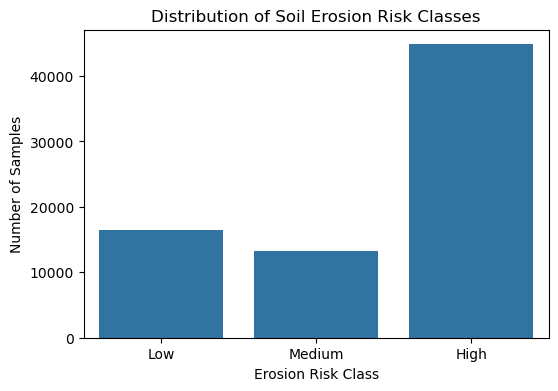

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='RUSLE_class',
              order=['Low', 'Medium', 'High'])
plt.title("Distribution of Soil Erosion Risk Classes")
plt.ylabel("Number of Samples")
plt.xlabel("Erosion Risk Class")
plt.show()

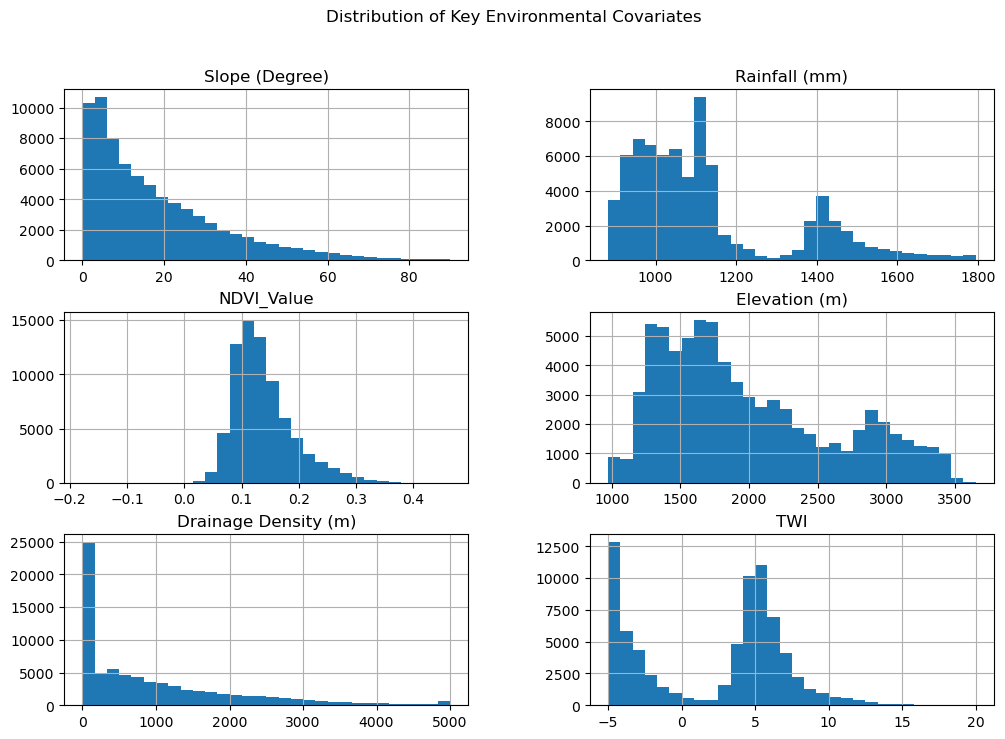

In [39]:
num_cols = [
    'Slope (Degree)', 'Rainfall (mm)', 'NDVI_Value',
    'Elevation (m)', 'Drainage Density (m)', 'TWI'
]

df[num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Key Environmental Covariates")
plt.show()


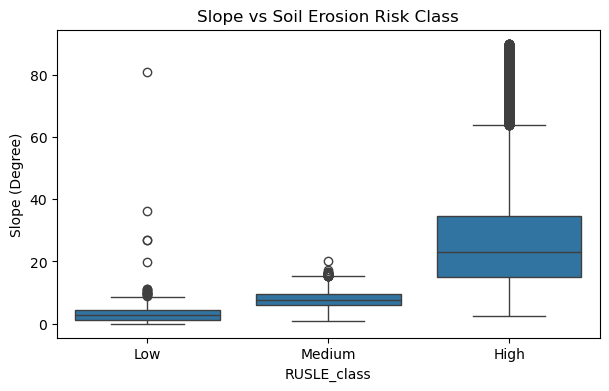

In [40]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='RUSLE_class', y='Slope (Degree)',
            order=['Low','Medium','High'])
plt.title("Slope vs Soil Erosion Risk Class")
plt.show()


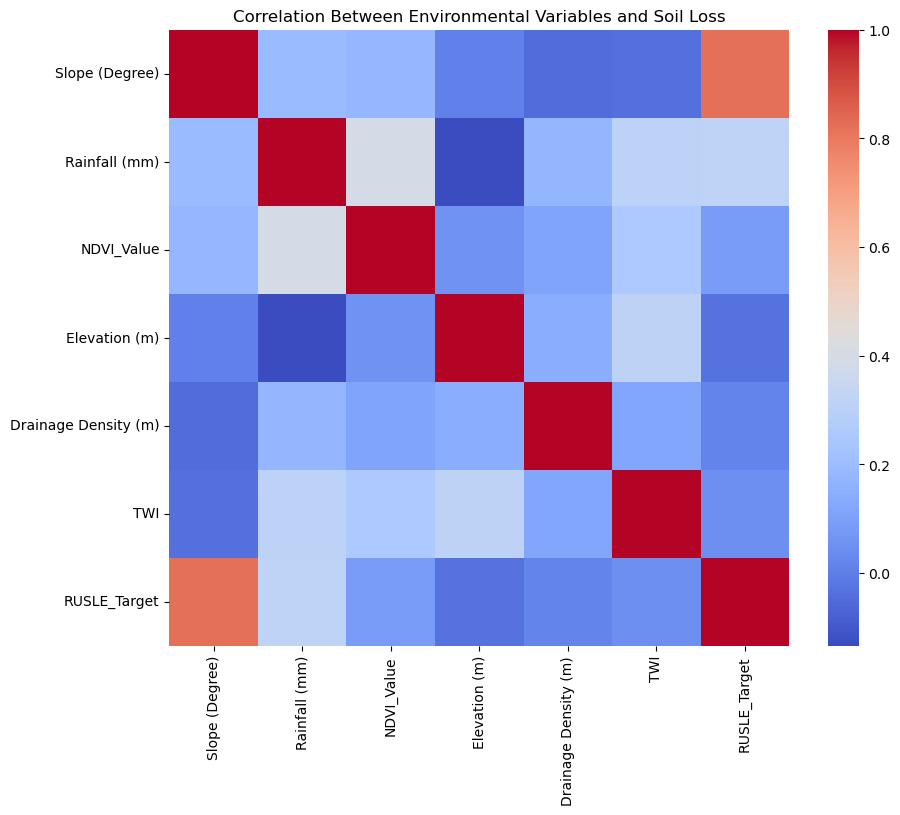

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols + ['RUSLE_Target']].corr(),
            cmap='coolwarm', annot=False)
plt.title("Correlation Between Environmental Variables and Soil Loss")
plt.show()


In [42]:
woreda_summary = df.groupby('Woreda')['RUSLE_Target'].mean().reset_index()
woreda_summary


,Woreda,RUSLE_Target
0,Ankober,499.737839
1,Kewet,439.612304
2,Menjar,86.789734
3,Menze Gera,284.571947
4,Merabete,385.598776


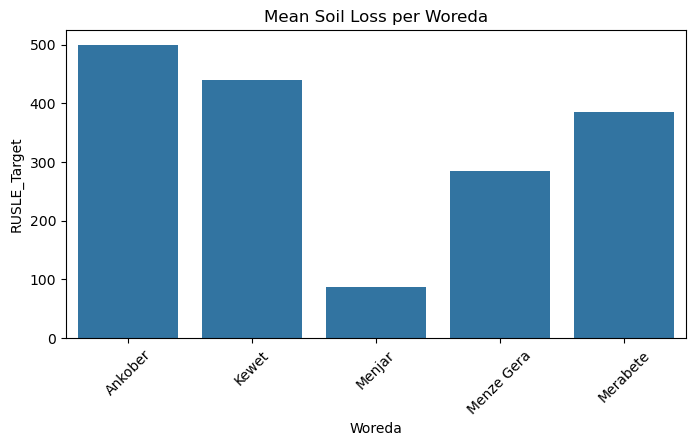

In [43]:
plt.figure(figsize=(8,4))
sns.barplot(data=woreda_summary,
            x='Woreda', y='RUSLE_Target')
plt.xticks(rotation=45)
plt.title("Mean Soil Loss per Woreda")
plt.show()


In [44]:
# Reset index to make it sequential
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_enc, dtype=torch.long)

# Dataset class
class SoilDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets & dataloaders
train_ds = SoilDataset(X_train_tensor, y_train_tensor)
test_ds  = SoilDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)


In [45]:
class ErosionNet(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)

        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)

        self.fc3 = nn.Linear(16, num_classes)

        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)

        self.act = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x


In [46]:
model = ErosionNet(X_train.shape[1])

In [47]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=5e-4)


In [48]:
EPOCHS = 50
patience = 5
best_acc = 0.0
counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # -------------------
    # TRAINING PHASE
    # -------------------
    model.train()
    train_loss = 0.0
    train_correct = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (preds.argmax(1) == yb).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_ds)

    # -------------------
    # VALIDATION PHASE
    # -------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = criterion(preds, yb)

            val_loss += loss.item()
            val_correct += (preds.argmax(1) == yb).sum().item()

    val_loss /= len(test_loader)
    val_acc = val_correct / len(test_ds)

    # -------------------
    # STORE METRICS
    # -------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # # -------------------
    # # EARLY STOPPING
    # # -------------------
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2%} | "
        f"Val Acc: {val_acc:.2%}"
    )

    if counter >= patience:
        print("Early stopping triggered.")
        break


Epoch 01 | Train Loss: 0.9536 | Train Acc: 56.08% | Val Acc: 68.18%
Epoch 02 | Train Loss: 0.6561 | Train Acc: 77.75% | Val Acc: 74.34%
Epoch 03 | Train Loss: 0.5068 | Train Acc: 84.50% | Val Acc: 83.37%
Epoch 04 | Train Loss: 0.4060 | Train Acc: 87.42% | Val Acc: 88.95%
Epoch 05 | Train Loss: 0.3416 | Train Acc: 89.34% | Val Acc: 91.38%
Epoch 06 | Train Loss: 0.3031 | Train Acc: 90.40% | Val Acc: 92.71%
Epoch 07 | Train Loss: 0.2814 | Train Acc: 91.07% | Val Acc: 93.57%
Epoch 08 | Train Loss: 0.2611 | Train Acc: 91.68% | Val Acc: 94.80%
Epoch 09 | Train Loss: 0.2404 | Train Acc: 92.23% | Val Acc: 94.93%
Epoch 10 | Train Loss: 0.2316 | Train Acc: 92.41% | Val Acc: 94.35%
Epoch 11 | Train Loss: 0.2215 | Train Acc: 92.76% | Val Acc: 94.70%
Epoch 12 | Train Loss: 0.2182 | Train Acc: 92.82% | Val Acc: 94.83%
Epoch 13 | Train Loss: 0.2090 | Train Acc: 93.00% | Val Acc: 95.46%
Epoch 14 | Train Loss: 0.1999 | Train Acc: 93.35% | Val Acc: 95.70%
Epoch 15 | Train Loss: 0.1959 | Train Acc: 93.52

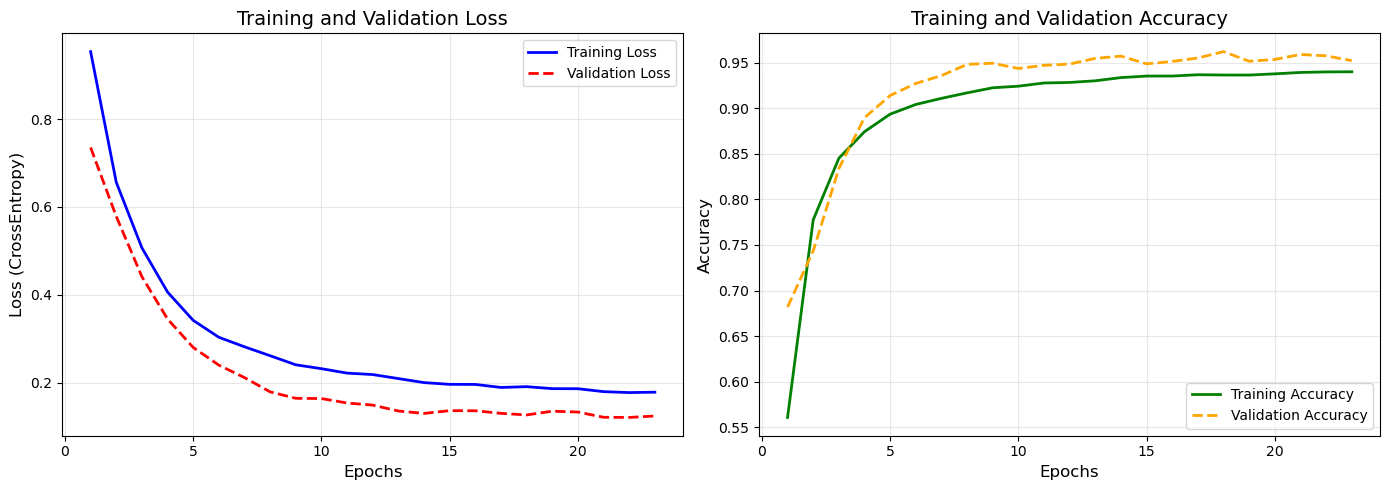

In [49]:
def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_losses, 'r--', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (CrossEntropy)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'g-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_accs, 'orange', linestyle='--', label='Validation Accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_metrics(train_losses, val_losses, train_accs, val_accs)


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        High       1.00      0.95      0.97     10353
         Low       0.95      0.96      0.95      2073
      Medium       0.79      0.94      0.86      2301

    accuracy                           0.95     14727
   macro avg       0.91      0.95      0.93     14727
weighted avg       0.96      0.95      0.95     14727



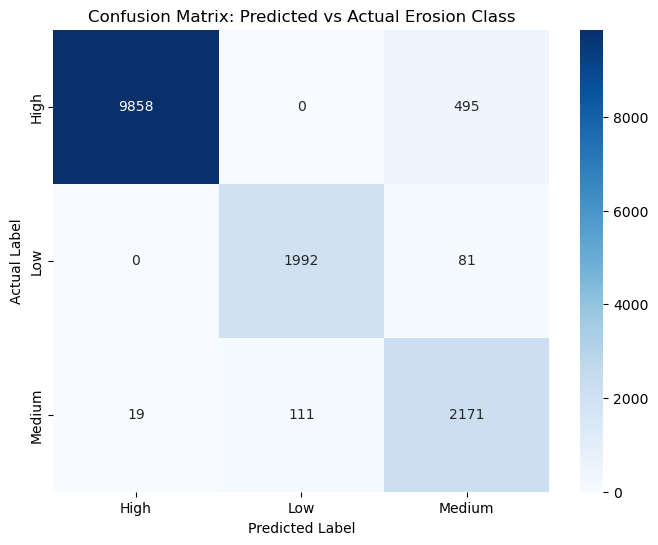

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_true.extend(yb.cpu().numpy())

# Map numbers back to original labels (e.g., 0 -> 'High', 1 -> 'Low')
label_names = le.classes_

print("\n--- Detailed Classification Report ---")
print(classification_report(all_true, all_preds, target_names=label_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix: Predicted vs Actual Erosion Class')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [51]:
import torch

MODEL_PATH = "erosionnet_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

In [52]:
import joblib

joblib.dump(scaler, "feature_scaler.pkl")

['feature_scaler.pkl']

In [53]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [54]:
import ee
import geemap
import torch
import torch.nn as nn
import joblib
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import Layout, VBox, HBox, HTML
from IPython.display import display, clear_output

# 1. INITIALIZE GEE
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

# 2. LOAD RESEARCH ARTIFACTS
MODEL_PATH = "erosionnet_model.pth"
SCALER_PATH = "feature_scaler.pkl"
COLUMNS_PATH = "feature_columns.pkl"

if not all(os.path.exists(f) for f in [MODEL_PATH, SCALER_PATH, COLUMNS_PATH]):
    print("⚠️ Missing artifacts. Ensure .pth and .pkl files are in the directory.")
else:
    feature_columns = joblib.load(COLUMNS_PATH)
    scaler = joblib.load(SCALER_PATH)
    scaler_features = list(scaler.feature_names_in_)
    INPUT_DIM = len(feature_columns)

# 3. DNN ARCHITECTURE (Strict 32-16-3)
class ErosionNet(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 32) 
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.fc3 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.3)
        self.act = nn.ReLU()

    def forward(self, x, mc_dropout=False):
        x = self.act(self.bn1(self.fc1(x)))
        if mc_dropout: x = torch.nn.functional.dropout(x, p=0.3, training=True)
        x = self.act(self.bn2(self.fc2(x)))
        if mc_dropout: x = torch.nn.functional.dropout(x, p=0.2, training=True)
        return self.fc3(x)

if 'INPUT_DIM' in locals():
    model = ErosionNet(input_dim=INPUT_DIM)
    model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    model.eval()

# 4. SCIENTIFIC UTILITIES
def calculate_rusle_baseline(phys_data):
    try:
        R = -8.12 + (0.562 * phys_data['Rainfall (mm)'])
        slope_rad = np.deg2rad(phys_data['Slope (Degree)'])
        LS = (phys_data['Slope (Degree)'] / 9)**1.3 
        C = np.exp(-2 * (phys_data['NDVI_Value'] / (1 - phys_data['NDVI_Value'] + 0.001)))
        K, P = 0.25, 1.0 
        A = R * K * LS * C * P
        if A < 15: return "Low", A
        elif A < 50: return "Medium", A
        else: return "High", A
    except: return "Unknown", 0.0

def get_intervention_advice(risk_class, uncert):
    if uncert > 8.0: return "⚠️ HIGH UNCERTAINTY: Field validation required."
    advice_map = {
        "High": "🛑 URGENT: Physical structures (Terracing, Soil Bunds) required.",
        "Medium": "🟡 ADVISORY: Biological measures (Agroforestry, Grass strips).",
        "Low": "✅ STABLE: Maintain existing cover; minimal intervention."
    }
    return advice_map.get(risk_class, "")

# 5. DATA EXTRACTION FUNCTIONS
def get_ethiopia_admin_full(lat, lon):
    try:
        admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM0_NAME', 'Ethiopia'))
        point = ee.Geometry.Point([lon, lat])
        match = admin2.filterBounds(point).first()
        info = match.getInfo()['properties']
        return f"Woreda: {info['ADM2_NAME']} | Zone: {info['ADM1_NAME']} | Ethiopia"
    except: return "Location: Ethiopian Highlands"

def get_gee_covariates(lat, lon):
    try:
        point = ee.Geometry.Point([lon, lat])
        buffer = point.buffer(100)
        dem = ee.Image('USGS/SRTMGL1_003')
        slope = ee.Terrain.slope(dem)
        aspect = ee.Terrain.aspect(dem)
        tpi = dem.subtract(dem.focal_mean(300, 'circle', 'meters'))
        l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(buffer).filterDate('2023-01-01', '2023-12-31').median()
        ndvi = l8.normalizedDifference(['SR_B5', 'SR_B4'])
        rain = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate('2023-01-01', '2023-12-31').select('precipitation').sum()
        lulc = ee.Image("ESA/WorldCover/v100/2020").select('Map')
        ferr = l8.select('SR_B6').divide(l8.select('SR_B7'))

        image = ee.Image.cat([dem.rename('elev'), slope.rename('slope'), 
                              aspect.multiply(np.pi/180).sin().rename('asin'),
                              aspect.multiply(np.pi/180).cos().rename('acos'),
                              ndvi.rename('ndvi'), rain.rename('rain'), 
                              tpi.rename('tpi'), lulc.rename('lulc'), ferr.rename('ferr')])
        return image.reduceRegion(reducer=ee.Reducer.mean(), geometry=buffer, scale=30).getInfo()
    except: return None

# 6. 3D VISUALIZATION
def plot_3d_decision_space(phys_base, phys_scen):
    n = 100
    low_cluster = np.random.multivariate_normal([5, 800, 0.6], [[2, 0, 0], [0, 5000, 0], [0, 0, 0.01]], n)
    high_cluster = np.random.multivariate_normal([25, 1400, 0.2], [[5, 0, 0], [0, 10000, 0], [0, 0, 0.01]], n)
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=low_cluster[:,0], y=low_cluster[:,1], z=low_cluster[:,2], mode='markers', marker=dict(size=2, color='green', opacity=0.2), name='Safe Zones'))
    fig.add_trace(go.Scatter3d(x=high_cluster[:,0], y=high_cluster[:,1], z=high_cluster[:,2], mode='markers', marker=dict(size=2, color='red', opacity=0.2), name='Danger Zones'))
    fig.add_trace(go.Scatter3d(x=[phys_base['Slope (Degree)']], y=[phys_base['Rainfall (mm)']], z=[phys_base['NDVI_Value']], mode='markers+text', name='Baseline', marker=dict(size=10, color='yellow', symbol='diamond', line=dict(color='black', width=2)), text=["Actual Site"]))
    fig.add_trace(go.Scatter3d(x=[phys_scen['Slope (Degree)']], y=[phys_scen['Rainfall (mm)']], z=[phys_scen['NDVI_Value']], mode='markers+text', name='Scenario', marker=dict(size=12, color='#3498db', symbol='circle', line=dict(color='white', width=2)), text=["Simulation"]))
    fig.update_layout(title="Multi-Covariate Susceptibility Space", scene=dict(xaxis_title='Slope', yaxis_title='Rain', zaxis_title='NDVI'), height=500, template="plotly_white", margin=dict(l=0, r=0, b=0, t=40))
    return fig

# 7. INFERENCE ENGINE
def run_inference(phys, lulc_str, mc_passes=25):
    final_input = {col: phys.get(col, 0.0) for col in feature_columns}
    for col in feature_columns:
        if "Land_Use_" in col:
            final_input[col] = 1.0 if col.replace("Land_Use_", "") == lulc_str else 0.0

    df = pd.DataFrame([final_input])[feature_columns]
    df[scaler_features] = scaler.transform(df[scaler_features])
    X_tensor = torch.tensor(df.to_numpy(), dtype=torch.float32)

    with torch.no_grad():
        mc_probs = [torch.softmax(model(X_tensor, mc_dropout=True), dim=1).numpy()[0] for _ in range(mc_passes)]
    
    mean_probs = np.array(mc_probs).mean(axis=0)
    uncert = np.mean(np.array(mc_probs).std(axis=0)) * 100 
    return ['Low', 'Medium', 'High'][np.argmax(mean_probs)], mean_probs, uncert

# 8. UI CONSTRUCTION & POLYGON MAPPING
# GEE GAUL ADM2_NAME mappings
woreda_boundary_names = {
    "Select Study Woreda": None,
    "Ankober": "Ankober",
    "Minjar": "Minjar Shenkora",
    "Merhabete": "Mera Bete",
    "Menz Gera": "Menz Gera Midir",
    "Kewet": "Kewet"
}

w_woreda = widgets.Dropdown(
    options=list(woreda_boundary_names.keys()),
    value="Select Study Woreda",
    description='<b>Woreda:</b>',
    style={'description_width': 'initial'}
)

w_lat = widgets.FloatText(value=9.505, description='<b>Lat:</b>')
w_lon = widgets.FloatText(value=40.189, description='<b>Lon:</b>')
w_btn = widgets.Button(description='Analyze Physical Susceptibility', button_style='primary', icon='flask', layout=Layout(width='95%'))

w_ndvi_delta = widgets.FloatSlider(value=0, min=-0.5, max=0.5, step=0.05, description='NDVI Delta')
w_rain_delta = widgets.IntSlider(value=0, min=-500, max=1000, step=50, description='Rain Delta')
w_lulc_mod = widgets.Dropdown(options=['No Change', 'Trees cover areas', 'Grassland', 'Cropland', 'Bare areas'], 
                              value='No Change', description='Policy Mod:')

w_out = widgets.Output()
Map = geemap.Map(center=[10.0, 39.5], zoom=8)
Map.add_basemap('HYBRID')

# LOAD GAUL FOR BOUNDARIES
woreda_fc = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM0_NAME', 'Ethiopia'))

def on_woreda_change(change):
    if change['new'] == "Select Study Woreda":
        return
    
    gee_name = woreda_boundary_names[change['new']]
    woreda_geom = woreda_fc.filter(ee.Filter.eq('ADM2_NAME', gee_name))
    
    # Extract Centroid for input boxes
    centroid = woreda_geom.geometry().centroid().getInfo()['coordinates']
    w_lat.value = round(centroid[1], 5)
    w_lon.value = round(centroid[0], 5)
    
    # UI Map Update
    # Use a clear name to prevent layer stacking
    Map.layers = [Map.layers[0]] # Keep Basemap
    Map.add_layer(woreda_geom, {'color': 'red'}, f"Boundary: {change['new']}")
    Map.center_object(woreda_geom)

w_woreda.observe(on_woreda_change, names='value')

def analyze(b):
    with w_out:
        clear_output()
        print("🌍 Querying physical covariates via Google Earth Engine...")
        
        # PhD Defense Note: Spatial coordinates are indices for physics retrieval, not model inputs.
        admin_info = get_ethiopia_admin_full(w_lat.value, w_lon.value)
        raw = get_gee_covariates(w_lat.value, w_lon.value)
        if not raw: return
            
        phys_base = {
            'Elevation (m)': float(raw.get('elev', 0)), 'Slope (Degree)': float(raw.get('slope', 0)),
            'Aspect_sin': float(raw.get('asin', 0)), 'Aspect_cos': float(raw.get('acos', 0)),
            'Rainfall (mm)': float(raw.get('rain', 0)), 'NDVI_Value': float(raw.get('ndvi', 0)),
            'TPI': float(raw.get('tpi', 0)), 'TWI': 8.5, 'Plan Curvature': 0.0, 'Profile Curvature': 0.0, 'Drainage Density (m)': 420.0
        }
        lulc_base = {10: 'Trees cover areas', 20: 'Shrubs cover areas', 30: 'Grassland', 40: 'Cropland', 50: 'Built up areas', 60: 'Bare areas'}.get(int(raw.get('lulc', 40)), 'Cropland')

        phys_scen = phys_base.copy()
        phys_scen['NDVI_Value'] = np.clip(phys_base['NDVI_Value'] + w_ndvi_delta.value, 0.01, 1)
        phys_scen['Rainfall (mm)'] = max(0, phys_base['Rainfall (mm)'] + w_rain_delta.value)
        lulc_scen = w_lulc_mod.value if w_lulc_mod.value != 'No Change' else lulc_base

        risk_b, probs_b, uncert_b = run_inference(phys_base, lulc_base)
        risk_s, probs_s, uncert_s = run_inference(phys_scen, lulc_scen)
        rusle_c, rusle_v = calculate_rusle_baseline(phys_base)
        advice = get_intervention_advice(risk_b, uncert_b)

        colors = {"Low": "#27ae60", "Medium": "#f39c12", "High": "#c0392b"}
        
        display(HTML(f"""
        <div style="background: #111; color: white; padding: 20px; border-radius: 12px; font-family: 'Segoe UI';">
            <h2 style="margin:0; color: #3498db;">📍 {admin_info}</h2>
            <div style="display: flex; gap: 15px; margin-top: 10px;">
                <div style="flex: 1; border: 1px solid #444; padding: 10px; border-radius: 8px;">
                    <h4 style="margin:0; color: #3498db;">🧠 AI SUSCEPTIBILITY</h4>
                    <h2 style="margin:5px 0; color: {colors[risk_b]};">{risk_b} Risk</h2>
                    <p style="font-size: 0.85em;">Prob: {np.max(probs_b)*100:.1f}% | Uncertainty: ±{uncert_b:.1f}%</p>
                </div>
                <div style="flex: 1; border: 1px solid #444; padding: 10px; border-radius: 8px;">
                    <h4 style="margin:0; color: #e67e22;">📖 RUSLE BASELINE</h4>
                    <h2 style="margin:5px 0; color: {colors.get(rusle_c, '#fff')};">{rusle_c}</h2>
                    <p style="font-size: 0.85em;">Est. Loss: {rusle_v:.1f} t/ha/yr</p>
                </div>
            </div>
            <div style="margin-top: 15px; padding: 15px; background: #2c3e50; border-radius: 8px;">
                <h4 style="margin:0; color: #f1c40f;">🏛️ POLICY RECOMMENDATION</h4>
                <p style="font-size: 0.95em;">{advice}</p>
            </div>
        </div>
        """))
        
        plot_3d_decision_space(phys_base, phys_scen).show()
        Map.add_marker([w_lat.value, w_lon.value], tooltip=f"Analysis: {risk_b}")

# Map Click listener
Map.on_interaction(lambda **kwargs: [setattr(w_lat, 'value', round(kwargs.get('coordinates')[0], 5)), 
                                     setattr(w_lon, 'value', round(kwargs.get('coordinates')[1], 5))] if kwargs.get('type') == 'click' else None)
w_btn.on_click(analyze)

ui = VBox([
    HTML("<h1 style='color:#2c3e50; margin:0;'>⛰️ Ethiopia Erosion Intelligence</h1>"),
    HTML("<p style='margin-bottom:10px;'>Official Woreda Boundaries & Counterfactual Analysis</p>"),
    w_woreda,
    HBox([w_lat, w_lon]),
    VBox([HTML("<h3>🔬 Scenario Laboratory</h3>"), w_lulc_mod, w_ndvi_delta, w_rain_delta, w_btn], 
         layout=Layout(padding='15px', background_color='#f4f4f4', border_radius='10px')),
    w_out
], layout=Layout(width='460px', padding='20px'))

print("Prediction is drive by environmental covariates, not spatial location.")
display(HBox([Map, ui]))

Prediction is drive by environmental covariates, not spatial location.
